# A word-level language model with an LSTM

A **language model** assigns a probability to the next word given the previous ones, $P(w_t \mid w_1, \dots, w_{t-1})$. Trained on a corpus, it can be used to score text or to generate new text one word at a time.

Recurrent neural networks process a sequence step by step while carrying a hidden state that summarizes what they have read so far. The **LSTM** (long short-term memory) adds gates that control what is kept and forgotten, which makes it much easier to train than a plain RNN.

In this notebook we:

1. prepare a corpus of 35,000 US political news headlines (2014–2022) and build a vocabulary;
2. train an LSTM language model, measuring **perplexity** on held-out headlines against simple n-gram baselines;
3. generate headlines with different **decoding strategies** (greedy, temperature sampling, top-k);
4. look at what the learned **word embeddings** capture.

In [1]:
import re
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

torch.manual_seed(0)
np.random.seed(0)
torch.set_num_threads(16)
plt.rcParams["figure.dpi"] = 100

## 1. Data and vocabulary

The headlines come from the politics section of a public news category dataset (HuffPost, 2014–2022). We lowercase them and split them into words and punctuation marks, then append an end-of-sentence token `<eos>` so that the model learns when a headline is finished.

In [2]:
headlines = pd.read_csv("data/political_headlines.csv", keep_default_na=False)
headlines = headlines[headlines["headline"].str.len() > 0]

def tokenize(text):
    return re.findall(r"\w+|[^\w\s]", text.lower())

tokens = [tokenize(h) + ["<eos>"] for h in headlines["headline"]]
lengths = pd.Series([len(t) for t in tokens])
counts = Counter(w for t in tokens for w in t)

print(f"{len(tokens):,} headlines, {sum(lengths):,} tokens, {len(counts):,} distinct tokens")
print(f"mean length: {lengths.mean():.1f} tokens")
print("most common:", counts.most_common(12))
for h in headlines["headline"].sample(5, random_state=1):
    print("  -", h)

35,601 headlines, 466,331 tokens, 19,192 distinct tokens
mean length: 13.1 tokens
most common: [('<eos>', 35601), ("'", 20510), ('to', 10745), ('trump', 10033), ('the', 9753), ('s', 9637), (',', 6255), ('.', 5781), ('of', 5567), ('in', 5361), (':', 5054), ('for', 4972)]
  - Chris Murphy Wants A New Progressive Foreign Policy
  - Hackers Breached U.S. Election Agency After Vote, According to Security Firm
  - Queen Elizabeth Tests Positive For COVID-19
  - It's Here: CBPP's Top Graphs Of The Year!
  - The Conservative Plot To Torpedo The Iran Deal In The Courts Has Begun


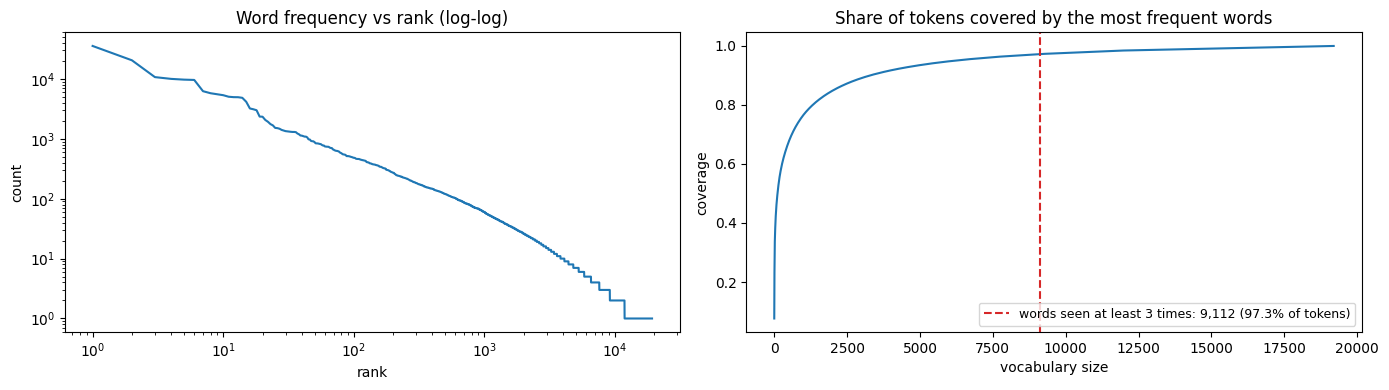

In [3]:
freq = np.array(sorted(counts.values(), reverse=True))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.loglog(np.arange(1, len(freq) + 1), freq)
ax1.set(title="Word frequency vs rank (log-log)", xlabel="rank", ylabel="count")
coverage = np.cumsum(freq) / freq.sum()
ax2.plot(np.arange(1, len(freq) + 1), coverage)
for k in (3,):
    n_words = (freq >= k).sum()
    ax2.axvline(n_words, color="tab:red", ls="--", label=f"words seen at least {k} times: {n_words:,} ({coverage[n_words - 1]:.1%} of tokens)")
ax2.set(title="Share of tokens covered by the most frequent words", xlabel="vocabulary size", ylabel="coverage")
ax2.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()

Word frequencies follow **Zipf's law**: a straight line on a log-log plot, with a few very common words and a long tail of words that appear only once or twice. Rare words cannot be learned reliably and make the output layer large and slow, so we keep only words seen at least 3 times. They cover about 97% of all tokens; every other word becomes `<unk>`.

In [4]:
vocab = ["<pad>", "<unk>", "<bos>"] + sorted(w for w, c in counts.items() if c >= 3)
word_to_id = {w: i for i, w in enumerate(vocab)}
PAD, UNK, BOS, EOS = word_to_id["<pad>"], word_to_id["<unk>"], word_to_id["<bos>"], word_to_id["<eos>"]
encode = lambda words: [word_to_id.get(w, UNK) for w in words]
print(f"vocabulary size: {len(vocab):,}")

# Each headline becomes (input, target): the target is the input shifted by one position.
sequences = [torch.tensor([BOS] + encode(t)) for t in tokens]
order = np.random.permutation(len(sequences))
n_val = len(sequences) // 10
val_seqs = [sequences[i] for i in order[:n_val]]
train_seqs = [sequences[i] for i in order[n_val:]]

def collate(batch):
    padded = nn.utils.rnn.pad_sequence(batch, batch_first=True, padding_value=PAD)
    return padded[:, :-1], padded[:, 1:]

train_loader = DataLoader(train_seqs, batch_size=64, shuffle=True, collate_fn=collate)
val_loader = DataLoader(val_seqs, batch_size=256, collate_fn=collate)
print(f"training headlines: {len(train_seqs):,}, validation headlines: {len(val_seqs):,}")
x, y = next(iter(train_loader))
print("input :", [vocab[i] for i in x[0] if i != PAD])
print("target:", [vocab[i] for i in y[0] if i != PAD])

vocabulary size: 9,115
training headlines: 32,041, validation headlines: 3,560
input : ['<bos>', 'even', 'waiting', 'on', 'the', 'pope', 'to', 'speak', 'couldn', "'", 't', 'keep', 'this', 'senator', 'from', 'getting', 'bored', '<eos>']
target: ['even', 'waiting', 'on', 'the', 'pope', 'to', 'speak', 'couldn', "'", 't', 'keep', 'this', 'senator', 'from', 'getting', 'bored', '<eos>']


## 2. Baselines: how predictable are headlines?

Language models are compared with **perplexity**, the exponential of the average cross-entropy on held-out text:

$$\text{PPL} = \exp\Big(-\frac{1}{N}\sum_{t} \log P(w_t \mid w_{<t})\Big).$$

It can be read as the number of words the model is "hesitating" between at each step: a uniform guess over the vocabulary gives a perplexity equal to its size (about 9,000), a perfect model gives 1.

Two classic baselines, estimated on the training headlines:

- **unigram**: every word is predicted by its overall frequency, ignoring context;
- **bigram**: the next word depends on the previous one, with add-$k$ smoothing so that unseen pairs keep a small probability.

In [5]:
train_tokens = torch.cat([s[1:] for s in train_seqs])
V = len(vocab)
unigram = torch.bincount(train_tokens, minlength=V).float() + 1
unigram /= unigram.sum()

pairs = torch.cat([torch.stack([s[:-1], s[1:]], 1) for s in train_seqs])
bigram_counts = Counter(map(tuple, pairs.tolist()))
prev_counts = Counter(pairs[:, 0].tolist())

def bigram_logprob(prev, nxt, k=0.01):
    return np.log((bigram_counts.get((prev, nxt), 0) + k * V * unigram[nxt].item()) / (prev_counts.get(prev, 0) + k * V))

val_pairs = torch.cat([torch.stack([s[:-1], s[1:]], 1) for s in val_seqs]).tolist()
ppl_unigram = np.exp(-np.mean([np.log(unigram[n].item()) for _, n in val_pairs]))
ppl_bigram = np.exp(-np.mean([bigram_logprob(p, n) for p, n in val_pairs]))
print(f"validation perplexity, unigram: {ppl_unigram:.0f}")
print(f"validation perplexity, bigram:  {ppl_bigram:.0f}")

validation perplexity, unigram: 751
validation perplexity, bigram:  232


Knowing only word frequencies leaves the model hesitating between hundreds of words; looking at one previous word helps a lot. An LSTM can use the whole headline read so far.

## 3. The LSTM language model

The architecture is simple:

- an **embedding** layer maps each word to a dense vector of 128 numbers;
- an **LSTM** with 512 hidden units reads the sequence;
- a **linear** layer maps each hidden state to a score for every word of the vocabulary.

Dropout on the embeddings and on the LSTM outputs regularizes the model, and the gradient norm is clipped to keep training stable (recurrent networks are prone to exploding gradients). The loss ignores padding positions.

In [6]:
class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden=512, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.lstm = nn.LSTM(emb_dim, hidden, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(hidden, vocab_size)

    def forward(self, x, state=None):
        h, state = self.lstm(self.dropout(self.embedding(x)), state)
        return self.output(self.dropout(h)), state

def evaluate(model, loader):
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for x, y in loader:
            logits, _ = model(x)
            loss = F.cross_entropy(logits.transpose(1, 2), y, ignore_index=PAD, reduction="sum")
            total += loss.item()
            n += (y != PAD).sum().item()
    return np.exp(total / n)

model = LSTMLanguageModel(V)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

parameters: 7,157,531


In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
history = []
start = time.time()
for epoch in range(1, 9):
    model.train()
    total, n = 0.0, 0
    for x, y in train_loader:
        optimizer.zero_grad()
        logits, _ = model(x)
        loss = F.cross_entropy(logits.transpose(1, 2), y, ignore_index=PAD)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tokens_in_batch = (y != PAD).sum().item()
        total += loss.item() * tokens_in_batch
        n += tokens_in_batch
    history.append({"epoch": epoch, "train perplexity": np.exp(total / n), "validation perplexity": evaluate(model, val_loader)})
print(f"training time: {(time.time() - start) / 60:.1f} min")
history = pd.DataFrame(history).set_index("epoch")
history.round(1)

training time: 42.0 min


,train perplexity,validation perplexity
epoch,,
1,390.8,208.2
2,179.0,154.0
3,128.0,137.3
4,102.4,131.5
5,86.3,129.1
6,75.2,129.9
7,67.1,131.0
8,60.8,133.4


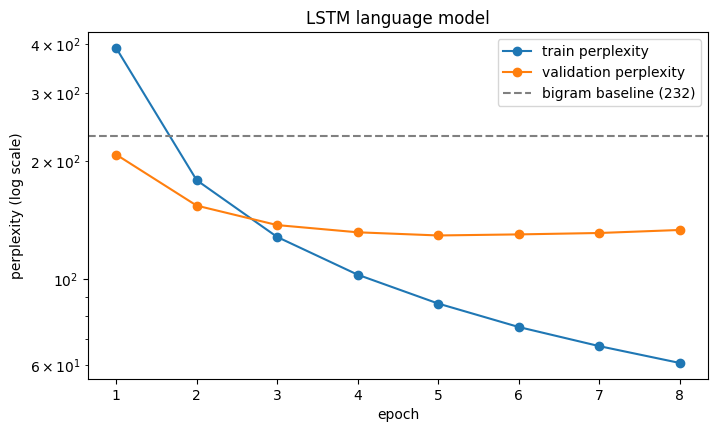

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
history.plot(ax=ax, marker="o")
ax.axhline(ppl_bigram, color="grey", ls="--", label=f"bigram baseline ({ppl_bigram:.0f})")
ax.set(yscale="log", ylabel="perplexity (log scale)", title="LSTM language model")
ax.legend()
plt.show()

The LSTM beats the bigram baseline (232) already after the first epoch, and its validation perplexity reaches a minimum of about 129 at epoch 5, roughly half the bigram value and a sixth of the unigram one. After that the training perplexity keeps falling while the validation perplexity rises: the model starts memorizing the training headlines. We keep the final model as it is, but in practice we would stop at the best epoch.

A validation perplexity in the low hundreds may sound high, but headlines are a hard target: they are short, dense with names and rare words, and give little context. Many continuations are genuinely plausible after "trump says", so even a perfect model would keep a high perplexity.

## 4. Generating headlines

To generate text we feed a prompt, read the probability distribution over the next word, choose a word, append it and repeat until `<eos>`. How the word is chosen matters a lot:

- **greedy**: always take the most likely word;
- **temperature sampling**: sample from the softmax of the scores divided by a temperature $T$; $T < 1$ makes the distribution sharper and safer, $T > 1$ flatter and more surprising;
- **top-k**: sample only among the $k$ most likely words.

In [9]:
def generate(model, prompt, strategy="sample", temperature=1.0, top_k=None, max_len=25):
    model.eval()
    ids = [BOS] + encode(tokenize(prompt))
    with torch.no_grad():
        logits, state = model(torch.tensor([ids]))
        for _ in range(max_len):
            scores = logits[0, -1]
            scores[UNK] = -float("inf")                  # never generate <unk>
            if strategy == "greedy":
                nxt = scores.argmax().item()
            else:
                if top_k:
                    cutoff = scores.topk(top_k).values[-1]
                    scores = scores.masked_fill(scores < cutoff, -float("inf"))
                nxt = torch.multinomial(F.softmax(scores / temperature, -1), 1).item()
            if nxt == EOS:
                break
            ids.append(nxt)
            logits, state = model(torch.tensor([[nxt]]), state)
    return " ".join(vocab[i] for i in ids[1:])

torch.manual_seed(1)
for prompt in ["the president wants", "democrats", "senate republicans"]:
    print(f"\nprompt: '{prompt}'")
    print("  greedy           :", generate(model, prompt, "greedy"))
    for T in (0.7, 1.0, 1.5):
        print(f"  temperature {T:<4} :", generate(model, prompt, temperature=T))
    print("  top-k (k = 10)   :", generate(model, prompt, top_k=10))


prompt: 'the president wants'
  greedy           : the president wants to know about the 2016 election


  temperature 0.7  : the president wants to say about the u . s . is dangerous about the high


  temperature 1.0  : the president wants to be cautious over climate change a convention


  temperature 1.5  : the president wants government come elect the alexandria ridiculous grows , lawmakers say store mother ' s wants of winning inside border just cannot ! to call cnn


  top-k (k = 10)   : the president wants a trump presidency and a new nickname

prompt: 'democrats'
  greedy           : democrats are trying to make it harder for the supreme court
  temperature 0.7  : democrats win a man on marijuana legalization
  temperature 1.0  : democrats seek trump ' s plan to pass military service after censoring : report
  temperature 1.5  : democrats absolutely heroes warning to becoming federal workers against student debt


  top-k (k = 10)   : democrats say they ' re doing anything from the people of a black friday

prompt: 'senate republicans'
  greedy           : senate republicans block trump ' s ' shithole ' comments
  temperature 0.7  : senate republicans talk to joe biden on ' unethical '
  temperature 1.0  : senate republicans block attempt to make its use of 9 / 11 heroes
  temperature 1.5  : senate republicans helping toddlers clerks created edge against women in post
  top-k (k = 10)   : senate republicans ' sit - - but not being a ' smart cookie '


The outputs show the typical behaviour of each strategy:

- **greedy** decoding produces the most fluent headlines ("democrats are trying to make it harder for the supreme court"), built from frequent phrases of the corpus, and the same prompt always gives the same result;
- **temperature 0.7**, **1.0** and **top-k** give more varied headlines that keep the style and grammar of the corpus for a few words but often lose the thread halfway;
- **temperature 1.5** samples from the long tail and quickly drifts into word salad.

The model has learned the *style* of political headlines, including their names, verbs and punctuation, but it has no notion of facts: a fluent headline can be entirely invented.

## 5. What do the embeddings capture?

The embedding layer gives every word a 128-dimensional vector, learned only to help predict the next word. Words used in similar contexts should end up with similar vectors. We look at the nearest neighbours by cosine similarity:

In [10]:
emb = F.normalize(model.embedding.weight.detach(), dim=1)

def neighbours(word, k=8):
    sims = emb @ emb[word_to_id[word]]
    best = sims.topk(k + 1).indices[1:]
    return ", ".join(f"{vocab[i]} ({sims[i]:.2f})" for i in best)

for word in ["trump", "obama", "senate", "democrats", "healthcare", "election", "says", "monday"]:
    print(f"{word:<11} -> {neighbours(word)}")

trump       -> warnock (0.36), obama (0.36), chafee (0.35), biden (0.35), tillerson (0.35), hannity (0.32), zinke (0.32), moore (0.31)
obama       -> trump (0.36), mccain (0.34), hernandez (0.33), pelosi (0.32), court (0.31), greene (0.31), records (0.31), decent (0.31)
senate      -> house (0.39), gubernatorial (0.34), latino (0.32), congressional (0.31), limited (0.30), signature (0.29), college (0.28), lifting (0.28)
democrats   -> republicans (0.35), solidarity (0.34), breakfast (0.33), journalists (0.33), they (0.33), kushner (0.33), senators (0.32), gunman (0.32)
healthcare  -> angela (0.38), patch (0.35), computers (0.32), just (0.32), display (0.31), prosecution (0.29), wonders (0.29), forfeiture (0.29)
election    -> obtains (0.32), sudden (0.32), concede (0.31), slashes (0.31), unraveling (0.30), wish (0.29), evolution (0.28), thisisnotus (0.28)
says        -> insists (0.40), admits (0.38), say (0.37), because (0.34), <bos> (0.33), attacking (0.32), urge (0.30), trashing (0.3

Even though the model was never told what words mean, several neighbourhoods make sense: the days of the week cluster tightly together (Monday's nearest neighbours are Tuesday, Wednesday, Thursday and Friday), "trump" sits among other politicians (Warnock, Obama, Biden, Tillerson), "senate" is closest to "house", "democrats" to "republicans", and "says" to other reporting verbs ("insists", "admits"). Other words, like "healthcare" and "election", have essentially random neighbours. These groupings emerge only from **distributional** information: words that can replace each other in a headline end up close together. With a small corpus and a model trained for next-word prediction rather than for embeddings, the neighbourhoods are noisy, and vector arithmetic analogies (like "king − man + woman") do not work reliably. Dedicated methods (word2vec, GloVe) or much larger models are needed for that.

## Summary

- A language model predicts the next word; **perplexity** on held-out text measures how well it does, and should be compared with simple **n-gram baselines**.
- Word frequencies follow **Zipf's law**: a vocabulary of the words seen at least a few times covers most tokens.
- An **LSTM** reading the whole prefix clearly beats unigram and bigram models, but it overfits after a few epochs on a small corpus, as the validation perplexity shows.
- The **decoding strategy** shapes the output as much as the model: greedy decoding is the most fluent but deterministic, sampling adds variety at the cost of coherence, and a high temperature produces word salad.
- **Embeddings** learned for next-word prediction capture similarity of usage, but they are noisy with limited data.